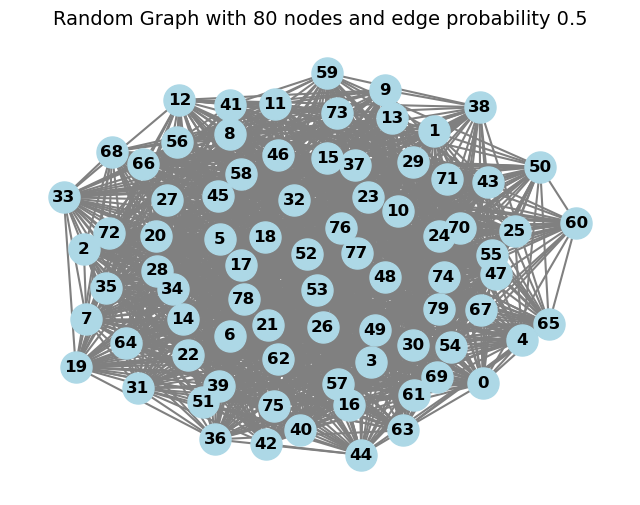

Generated Graph Adjacency Matrix:
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]


In [ ]:
import numpy as np
from qihc import IsingModel
from qihc.ising import maxcut

# maxcut demo
if __name__ == "__main__":
    G = maxcut.generate_random_graph(80, 0.5)
    print("Generated Graph Adjacency Matrix:\n", G.nodes())

In [ ]:
# Brute-force Max-Cut (iterative over all possible partitions)
max_cut_value, best_cut = maxcut.brute_force_max_cut(G)
print("Brute-Force Max-Cut Value:", max_cut_value)
print("Brute-Force Max-Cut Sets:", best_cut)
maxcut.plot_partition(G, best_cut)

In [ ]:
# Brute-force Balanced Max-Cut (iterative over all possible balanced partitions)
max_cut_value, best_cut = maxcut.brute_force_max_cut_balanced(G)
print("Brute-Force Balanced Max-Cut Value:", max_cut_value)
print("Brute-Force Balanced Max-Cut Sets:", best_cut)
maxcut.plot_partition(G, best_cut)

# Orginal Simulated Annealing

Max-Cut Sets from Simulated Annealing:
Set 1: {0, 4, 7, 8, 10, 11, 15, 18, 19, 21, 22, 23, 25, 26, 29, 30, 31, 34, 35, 38, 40, 41, 42, 43, 50, 51, 52, 56, 58, 59, 60, 62, 63, 71, 72, 73, 75, 77, 78, 79}
Set 2: {1, 2, 3, 5, 6, 9, 12, 13, 14, 16, 17, 20, 24, 27, 28, 32, 33, 36, 37, 39, 44, 45, 46, 47, 48, 49, 53, 54, 55, 57, 61, 64, 65, 66, 67, 68, 69, 70, 74, 76}
Cut Value: 932


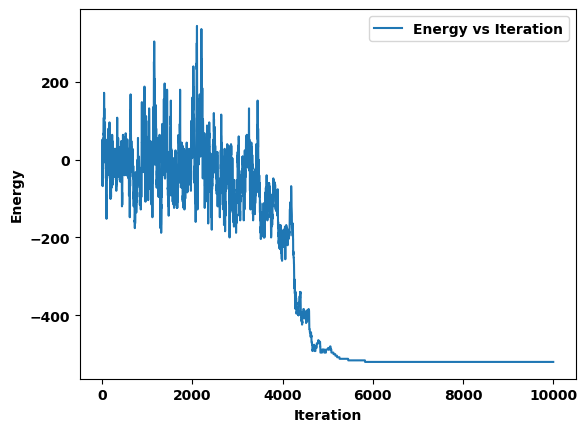

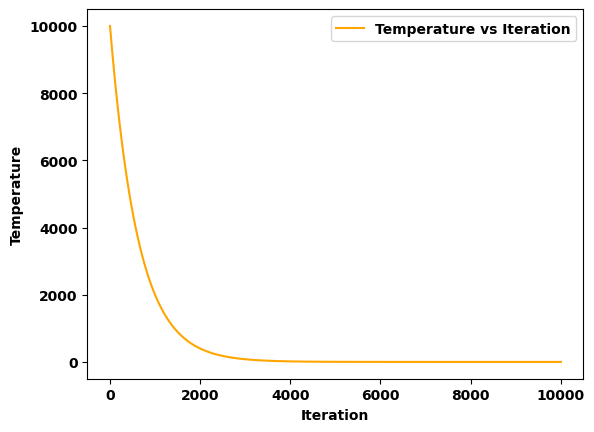

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
import numpy as np

J = maxcut.max_cut_to_ising(G)
iteration_value = 10000
spins, current_energy_list, temperature_list = maxcut.ising_simulated_annealing(J, steps=iteration_value, T_start=10000.0, T_end=0.001)
set1, set2 = maxcut.convert_spins_to_cut(spins)
print("Max-Cut Sets from Simulated Annealing:")
print("Set 1:", set1)
print("Set 2:", set2)
print("Cut Value:", maxcut.calculate_cut_value(G, (set1, set2)))
plt.figure(dpi=100)
iteration_list = np.linspace(1, iteration_value, len(temperature_list))
plt.plot(iteration_list, current_energy_list, label='Energy vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.legend()
    
plt.figure(dpi=100)
plt.plot(iteration_list, temperature_list, label='Temperature vs Iteration', c='orange')
plt.xlabel('Iteration')
plt.ylabel('Temperature')
plt.legend()

# P-bit asynchronous update

Max-Cut Sets from P-bit Simulated Annealing:
Set 1: {0, 4, 5, 6, 9, 10, 11, 12, 13, 14, 15, 19, 20, 22, 24, 26, 29, 31, 33, 35, 39, 42, 43, 44, 47, 49, 51, 52, 55, 58, 59, 60, 62, 63, 69, 70, 72, 74, 77, 78}
Set 2: {1, 2, 3, 7, 8, 16, 17, 18, 21, 23, 25, 27, 28, 30, 32, 34, 36, 37, 38, 40, 41, 45, 46, 48, 50, 53, 54, 56, 57, 61, 64, 65, 66, 67, 68, 71, 73, 75, 76, 79}
Cut Value: 923


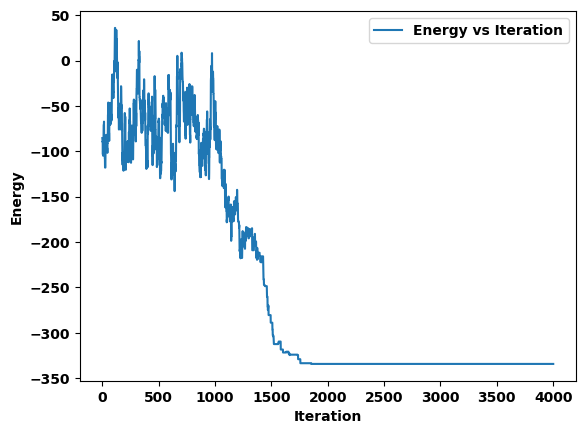

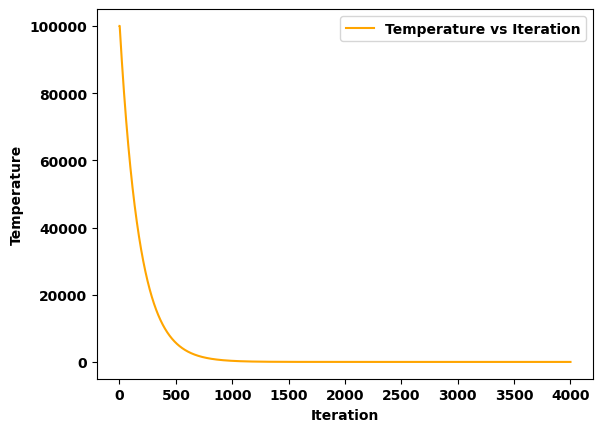

In [7]:
import numpy as np
from matplotlib import pyplot as plt
from qihc import IsingModel
from qihc.ising import maxcut

P_bit_model = IsingModel(size=80)
J = maxcut.max_cut_to_ising(G)
# print("Interaction Matrix J:\n", J)
iteration_value = 4000
spins, current_energy_list, temperature_list = P_bit_model.ising_simulated_annealing_Maxcut_Asyn(J, steps=iteration_value, T_start=100000, T_end=0.00001, k=10)
set1, set2 = maxcut.convert_spins_to_cut(spins)
print("Max-Cut Sets from P-bit Simulated Annealing:")
print("Set 1:", set1)
print("Set 2:", set2)
print("Cut Value:", maxcut.calculate_cut_value(G, (set1, set2)))
plt.figure(dpi=100)
iteration_list = np.linspace(1, iteration_value, len(temperature_list))
plt.plot(iteration_list, current_energy_list, label='Energy vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.legend()
    
plt.figure(dpi=100)
plt.plot(iteration_list, temperature_list, label='Temperature vs Iteration', c='orange')
plt.xlabel('Iteration')
plt.ylabel('Temperature')
plt.legend()

# P-bit synchronous update

Max-Cut Sets from P-bit Simulated Annealing:
Set 1: {2, 4, 5, 9, 12, 14, 16, 17, 18, 19, 20, 22, 23, 24, 25, 27, 29, 32, 34, 37, 40, 42, 43, 44, 45, 48, 49, 50, 54, 59, 62, 65, 66, 67, 69, 74, 75, 76, 77, 78}
Set 2: {0, 1, 3, 6, 7, 8, 10, 11, 13, 15, 21, 26, 28, 30, 31, 33, 35, 36, 38, 39, 41, 46, 47, 51, 52, 53, 55, 56, 57, 58, 60, 61, 63, 64, 68, 70, 71, 72, 73, 79}
Cut Value: 914


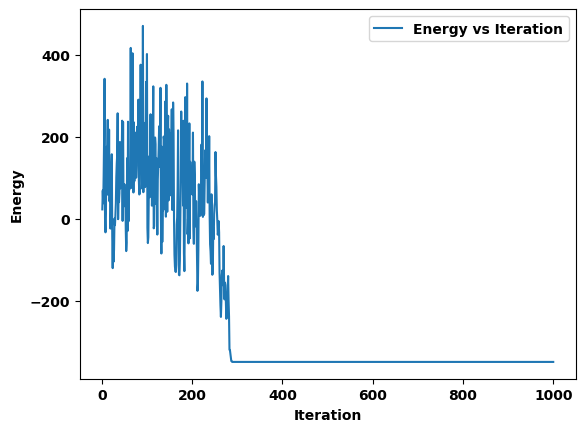

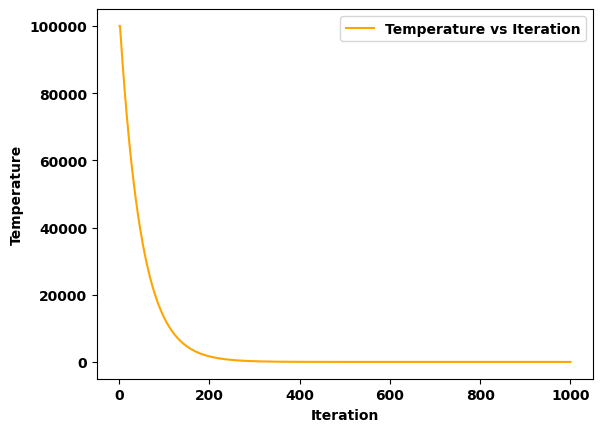

In [31]:

P_bit_model = IsingModel(size=80)
J = maxcut.max_cut_to_ising(G)
# print("Interaction Matrix J:\n", J)
iteration_value = 1000
spins, current_energy_list, temperature_list = P_bit_model.ising_simulated_annealing_Maxcut_Syn(J, steps=iteration_value, T_start=100000, T_end=0.0001, k=10)
set1, set2 = maxcut.convert_spins_to_cut(spins)
print("Max-Cut Sets from P-bit Simulated Annealing:")
print("Set 1:", set1)
print("Set 2:", set2)
print("Cut Value:", maxcut.calculate_cut_value(G, (set1, set2)))
plt.figure(dpi=100)
iteration_list = np.linspace(1, iteration_value, len(temperature_list))
plt.plot(iteration_list, current_energy_list, label='Energy vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.legend()
    
plt.figure(dpi=100)
plt.plot(iteration_list, temperature_list, label='Temperature vs Iteration', c='orange')
plt.xlabel('Iteration')
plt.ylabel('Temperature')
plt.legend()

# Gibbs / Parallel Tempering / SQA（新增采样内核）

以下三种算法已集成至 `Ising_model.py`，接口与 SA 方法一致，可直接用于 Max-Cut / Ising 求解。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qihc import IsingModel
from qihc.ising import maxcut

# 复用上文生成的图 G；若单独运行本 cell，请取消下一行注释
# G = maxcut.generate_random_graph(30, 0.5, seed=0)
J = maxcut.max_cut_to_ising(G)
steps = 1500
kwargs = dict(J=J, steps=steps, T_start=10.0, T_end=0.01, k=1.0)

model = IsingModel(size=len(G.nodes()))
spins_g, e_g, _ = model.gibbs_sampling_Maxcut(**kwargs, sequential=True)
cut_g = maxcut.calculate_cut_value(G, maxcut.convert_spins_to_cut(spins_g))

model = IsingModel(size=len(G.nodes()))
spins_pt, e_pt, temps = model.parallel_tempering_Maxcut(**kwargs, n_replicas=6, swap_interval=15)
cut_pt = maxcut.calculate_cut_value(G, maxcut.convert_spins_to_cut(spins_pt))

model = IsingModel(size=len(G.nodes()))
spins_sqa, e_sqa, gamma_trace = model.simulated_quantum_annealing_Maxcut(
    **kwargs, Gamma_start=3.0, Gamma_end=0.01, m_slices=6
)
cut_sqa = maxcut.calculate_cut_value(G, maxcut.convert_spins_to_cut(spins_sqa))

print(f"Gibbs cut={cut_g}, PT cut={cut_pt}, SQA cut={cut_sqa}")

plt.figure(dpi=100)
plt.plot(e_g, label='Gibbs')
plt.plot(e_pt, label='Parallel Tempering')
plt.plot(e_sqa, label='SQA')
plt.xlabel('Sweep / step')
plt.ylabel('Ising energy')
plt.legend()
plt.title('Energy convergence: Gibbs vs PT vs SQA')
plt.show()